In [1]:
!nvidia-smi
%matplotlib inline

Sun Apr 12 00:30:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100                    On  |   00000000:A6:00.0 Off |                    0 |
| N/A   33C    P0             67W /  700W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from helper_functions_testing import (
    batch_generate_responses_qwen3,
    get_judgments_from_responses,
    run_experiment,
    retrieve_results,
    prepare_test_prompts,
    obtain_results_without)
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
import pandas as pd
import json
import re
import numpy as np
from typing import List, Optional, Dict, Any
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm import tqdm
import torch

In [6]:
import os
print("HF_HOME:", os.environ.get("HF_HOME"))
print("HF_DATASETS_CACHE:", os.environ.get("HF_DATASETS_CACHE"))
print("HF_HUB_CACHE:", os.environ.get("HF_HUB_CACHE"))
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

# 可选：确保没被错误地关掉进度条
os.environ.pop("HF_HUB_DISABLE_PROGRESS_BARS", None)

HF_HOME: /scratch-local/yhuang/huggingface_cache
HF_DATASETS_CACHE: /scratch-local/yhuang/huggingface_cache/datasets
HF_HUB_CACHE: /scratch-local/yhuang/huggingface_cache/hub


### Loading verified examples (UNDER_gold)

In [4]:
verified_examples = "../Data/UNDER_gold.csv"
df_verified_examples = pd.read_csv(verified_examples)

### Qwen3-8B

In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM
Qwen3_8B = "Qwen/Qwen3-8B"
tokenizer = AutoTokenizer.from_pretrained(Qwen3_8B, padding_side='left')
model = AutoModelForCausalLM.from_pretrained(Qwen3_8B)
# 将模型移到可用设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

/home/yhuang/ondemand/paper_clean/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 5/5 [00:26<00:00,  5.22s/it]


cuda


In [7]:
system_prompt = """
You are an expert analyst. Your task is to analyze and determine whether an input user query is "fully specified" or "underspecified".

"""

task_FS_UND = """
Analyze the following input user query:

{"query": "TARGET"}

Please provide your analysis in the following JSON format:

{"query": "TARGET", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}
"""

In [8]:
test_prompts = prepare_test_prompts(df_verified_examples, task_FS_UND)
print(test_prompts[0])

Start preparing prompts...
# Testing data points: 150
Generation complete: 150 prompts
Average prompt length: 331 bytes (~82 tokens)

Analyze the following input user query:

{"query": "When was the first world war broke out?"}

Please provide your analysis in the following JSON format:

{"query": "When was the first world war broke out?", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}



In [9]:
test_df = run_experiment(tokenizer, model, test_prompts, system_prompt, df_verified_examples)
test_df

100%|██████████| 30/30 [20:14<00:00, 40.48s/it]


,Unnamed: 0,request,gold_judgment,direct_source,category,reasoning,original_annotation,thinking,model_response,model_pred
0,1118,When was the first world war broke out?,underspecified,AmbigNQ,Undetermined perspective or granularity,The phrase “broke out” can be interpreted from...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's tackle this query: ""When ...","{\n ""query"": ""When was the first world war br...",fully specified
1,5585,Who sings the song i will try to fix you?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question allows multiple granularities: it...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's tackle this query. The us...","{\n ""query"": ""Who sings the song i will try t...",underspecified
2,9330,Who is the head of the nation in india?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question can refer to the role or title of...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's tackle this query: ""Who i...","{\n ""query"": ""Who is the head of the nation i...",fully specified
3,9602,Moss is an example of which type of plant?,underspecified,AmbigNQ,Undetermined perspective or granularity,The term “type” can refer to different taxonom...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's take a look at this query...","{\n ""query"": ""Moss is an example of which typ...",fully specified
4,4145,How long can you serve in the house?,underspecified,AmbigNQ,"Undetermined lexicons or references, Undetermi...",The term “house” is referentially ambiguous be...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's tackle this query: ""How l...","{\n ""query"": ""How long can you serve in the h...",underspecified
...,...,...,...,...,...,...,...,...,...,...
145,1213,Give me a bulleted list of the 5 highest mount...,fully specified,CLAMBER,fully specified,This question is fully specified because it re...,NaN,"<think>\nOkay, let's tackle this query analysi...","{\n ""query"": ""Give me a bulleted list of the ...",fully specified
146,2274,Who is the author of the novel Taipei by Tao Lin?,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"<think>\nOkay, let's take a look at this query...","{\n ""query"": ""Who is the author of the novel ...",fully specified
147,356,What's the average body length of Brania russe...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"<think>\nOkay, let me tackle this query. The u...","{\n ""query"": ""What's the average body length ...",underspecified
148,294,Is Bolusia capensis a unicellular organism in ...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"<think>\nOkay, let's tackle this query: ""Is Bo...","{\n ""query"": ""Is Bolusia capensis a unicellul...",fully specified


No error found, directly process the data.
                 precision    recall  f1-score   support

fully specified       0.57      0.65      0.61        51
 underspecified       0.80      0.75      0.77        99

       accuracy                           0.71       150
      macro avg       0.69      0.70      0.69       150
   weighted avg       0.72      0.71      0.72       150



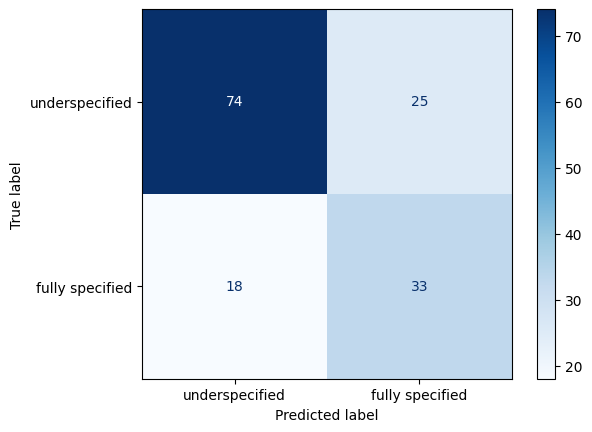

In [10]:
retrieve_results(test_df, "Qwen3_8B_verified_test")

### Qwen3-14B

In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM
Qwen3_14B = "Qwen/Qwen3-14B"
tokenizer = AutoTokenizer.from_pretrained(Qwen3_14B, padding_side='left')
model = AutoModelForCausalLM.from_pretrained(Qwen3_14B)
# 将模型移到可用设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

/home/yhuang/ondemand/paper_clean/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 8/8 [00:35<00:00,  4.46s/it]


cuda


In [8]:
system_prompt = """
You are an expert analyst. Your task is to analyze and determine whether an input user query is "fully specified" or "underspecified".

"""

task_FS_UND = """
Analyze the following input user query:

{"query": "TARGET"}

Please provide your analysis in the following JSON format:

{"query": "TARGET", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}
"""

In [9]:
test_prompts = prepare_test_prompts(df_verified_examples, task_FS_UND)
print(test_prompts[0])

Start preparing prompts...
# Testing data points: 150
Generation complete: 150 prompts
Average prompt length: 331 bytes (~82 tokens)

Analyze the following input user query:

{"query": "When was the first world war broke out?"}

Please provide your analysis in the following JSON format:

{"query": "When was the first world war broke out?", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}



In [10]:
test_df = run_experiment(tokenizer, model, test_prompts, system_prompt, df_verified_examples)
test_df

100%|██████████| 30/30 [15:57<00:00, 31.90s/it]


,Unnamed: 0,request,gold_judgment,direct_source,category,reasoning,original_annotation,thinking,model_response,model_pred
0,1118,When was the first world war broke out?,underspecified,AmbigNQ,Undetermined perspective or granularity,The phrase “broke out” can be interpreted from...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's take a look at this query...","{\n ""query"": ""When was the first world war br...",fully specified
1,5585,Who sings the song i will try to fix you?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question allows multiple granularities: it...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's take a look at this query...","{\n ""query"": ""Who sings the song i will try t...",fully specified
2,9330,Who is the head of the nation in india?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question can refer to the role or title of...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's tackle this query. The us...","{\n ""query"": ""Who is the head of the nation i...",fully specified
3,9602,Moss is an example of which type of plant?,underspecified,AmbigNQ,Undetermined perspective or granularity,The term “type” can refer to different taxonom...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's see here. The user asked,...","{\n ""query"": ""Moss is an example of which typ...",fully specified
4,4145,How long can you serve in the house?,underspecified,AmbigNQ,"Undetermined lexicons or references, Undetermi...",The term “house” is referentially ambiguous be...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's take a look at this query...","{\n ""query"": ""How long can you serve in the h...",underspecified
...,...,...,...,...,...,...,...,...,...,...
145,1213,Give me a bulleted list of the 5 highest mount...,fully specified,CLAMBER,fully specified,This question is fully specified because it re...,NaN,"<think>\nOkay, let's tackle this query. The us...","{\n ""query"": ""Give me a bulleted list of the ...",fully specified
146,2274,Who is the author of the novel Taipei by Tao Lin?,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"<think>\nOkay, let's see here. The user is ask...","{\n ""query"": ""Who is the author of the novel ...",underspecified
147,356,What's the average body length of Brania russe...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"<think>\nOkay, let me think about this. The us...","{\n ""query"": ""What's the average body length ...",fully specified
148,294,Is Bolusia capensis a unicellular organism in ...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"<think>\nOkay, let's see. The user is asking i...","{\n ""query"": ""Is Bolusia capensis a unicellul...",fully specified


No error found, directly process the data.
                 precision    recall  f1-score   support

fully specified       0.51      0.75      0.60        51
 underspecified       0.83      0.63      0.71        99

       accuracy                           0.67       150
      macro avg       0.67      0.69      0.66       150
   weighted avg       0.72      0.67      0.68       150



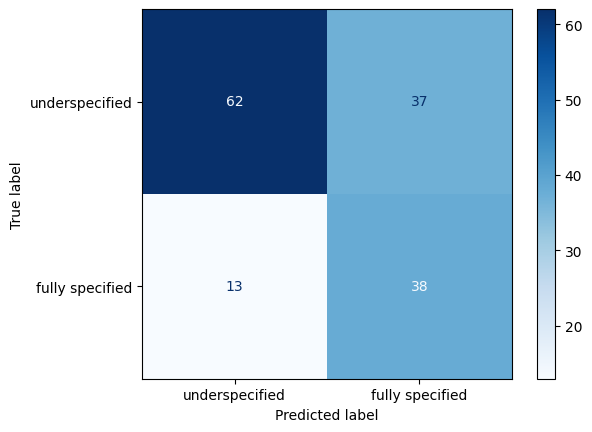

In [11]:
retrieve_results(test_df, "Qwen3_14B_verified_test")

### Qwen3-32B

In [ ]:
# Using sglang to run the larger model

Qwen_32B = "Qwen/Qwen3-32B"

"""
module load 2023
module load CUDA/12.4.0
source ~/sglang-venv-2/bin/activate
huggingface-cli login


# 创建所有必要的目录
mkdir -p /scratch-local/yhuang/sglang_cache
mkdir -p /scratch-local/yhuang/huggingface_cache
mkdir -p /scratch-local/yhuang/torch_cache
mkdir -p /scratch-local/yhuang/cuda_cache
mkdir -p /scratch-local/yhuang/xdg_cache
mkdir -p /scratch-local/yhuang/tmp
mkdir -p /scratch-local/yhuang/logs

# 设置所有相关环境变量
export SGLANG_CACHE_DIR=/scratch-local/yhuang/sglang_cache
export TRANSFORMERS_CACHE=/scratch-local/yhuang/huggingface_cache
export HF_HOME=/scratch-local/yhuang/huggingface_cache
export HF_DATASETS_CACHE=/scratch-local/yhuang/huggingface_cache/datasets
export TORCH_HOME=/scratch-local/yhuang/torch_cache
export CUDA_CACHE_PATH=/scratch-local/yhuang/cuda_cache
export XDG_CACHE_HOME=/scratch-local/yhuang/xdg_cache
export TMPDIR=/scratch-local/yhuang/tmp
export TEMP=/scratch-local/yhuang/tmp
export TMP=/scratch-local/yhuang/tmp
export SGLANG_LOG_DIR=/scratch-local/yhuang/logs

# launching
python -m sglang.launch_server --port 7501 --model-path Qwen/Qwen3-4B --trust-remote-code
CUDA_VISIBLE_DEVICES=0,1 python -m sglang.launch_server --port 7501 --model-path Qwen/Qwen3-32B --trust-remote-code --tp 2
"""

In [5]:
system_prompt = """
You are an expert analyst. Your task is to analyze and determine whether an input user query is "fully specified" or "underspecified".

"""

task_FS_UND = """
Analyze the following input user query:

{"query": "TARGET"}

Please provide your analysis in the following JSON format:

{"query": "TARGET", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}
"""

In [6]:
import openai
import re
client = openai.Client(
    base_url="http://localhost:7501/v1", api_key="EMPTY")


def batch_generate_responses_openai(prompts, system_prompt=system_prompt,
                            temperature=0.7, max_new_tokens=32768, batch_size=5,
                            enable_thinking=True):
    responses = []
    thoughts = []

    for i in tqdm(range(0, len(prompts), batch_size)):
        batch_prompts = prompts[i:i+batch_size]
        batch_responses = []
        batch_thoughts = []

        for prompt in batch_prompts:
            try:
                kwargs = {
                    "model": "Qwen/Qwen3-32B",
                    "messages": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": prompt},
                    ],
                    "temperature": temperature,
                    "max_tokens": max_new_tokens,
                    "extra_body": {"chat_template_kwargs": {"enable_thinking": False}}
                }

                # 仅当enable_thinking为True时添加思考模式参数
                if enable_thinking:
                    kwargs["extra_body"] = {"chat_template_kwargs": {"enable_thinking": True}}

                response = client.chat.completions.create(**kwargs)
                full_text = response.choices[0].message.content

                # 仅在enable_thinking为True时尝试分离思考过程
                if enable_thinking:
                    try:
                        end_think_pos = full_text.find('</think>')

                        if end_think_pos != -1:
                            thought = full_text[:end_think_pos].strip()
                            answer = full_text[end_think_pos + len('</think>'):].strip()
                        else:
                            thought = ""
                            answer = full_text
                    except Exception as parsing_error:
                        print(f"解析思考过程时出错: {parsing_error}")
                        thought = ""
                        answer = full_text
                else:
                    # 当enable_thinking为False时，不分离思考过程
                    thought = ""
                    answer = full_text

                batch_responses.append(answer)
                batch_thoughts.append(thought)

            except Exception as e:
                print(f"API调用时出错: {e}")
                batch_responses.append(None)
                batch_thoughts.append(None)

        responses.extend(batch_responses)
        thoughts.extend(batch_thoughts)

    return responses, thoughts

def run_experiment_openai(input_prompts, test_df):
  output = batch_generate_responses_openai(input_prompts)
  df = test_df.copy()
  df['thinking'] = output[1]
  df['model_response'] = output[0]
  to_process = output[0]
  processed_judgments = get_judgments_from_responses(to_process)
  df['model_pred'] = processed_judgments

  return df

In [7]:
test_prompts = prepare_test_prompts(df_verified_examples, task_FS_UND)
print(test_prompts[0])

Start preparing prompts...
# Testing data points: 150
Generation complete: 150 prompts
Average prompt length: 331 bytes (~82 tokens)

Analyze the following input user query:

{"query": "When was the first world war broke out?"}

Please provide your analysis in the following JSON format:

{"query": "When was the first world war broke out?", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}



In [8]:
test_df = run_experiment_openai(test_prompts, df_verified_examples)
test_df

100%|██████████| 30/30 [20:03<00:00, 40.13s/it]


,Unnamed: 0,request,gold_judgment,direct_source,category,reasoning,original_annotation,thinking,model_response,model_pred
0,1118,When was the first world war broke out?,underspecified,AmbigNQ,Undetermined perspective or granularity,The phrase “broke out” can be interpreted from...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's tackle this query. The us...","{""query"": ""When was the first world war broke ...",fully specified
1,5585,Who sings the song i will try to fix you?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question allows multiple granularities: it...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's analyze the user's query:...","{""query"": ""Who sings the song i will try to fi...",fully specified
2,9330,Who is the head of the nation in india?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question can refer to the role or title of...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's tackle this user query: ""...","{""query"": ""Who is the head of the nation in in...",underspecified
3,9602,Moss is an example of which type of plant?,underspecified,AmbigNQ,Undetermined perspective or granularity,The term “type” can refer to different taxonom...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's tackle this query. The us...","{""query"": ""Moss is an example of which type of...",fully specified
4,4145,How long can you serve in the house?,underspecified,AmbigNQ,"Undetermined lexicons or references, Undetermi...",The term “house” is referentially ambiguous be...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","<think>\nOkay, let's see. The user is asking, ...","{""query"": ""How long can you serve in the house...",underspecified
...,...,...,...,...,...,...,...,...,...,...
145,1213,Give me a bulleted list of the 5 highest mount...,fully specified,CLAMBER,fully specified,This question is fully specified because it re...,NaN,"<think>\nOkay, let's analyze this user query. ...","{""query"": ""Give me a bulleted list of the 5 hi...",fully specified
146,2274,Who is the author of the novel Taipei by Tao Lin?,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"<think>\nOkay, let's look at this query. The u...","{""query"": ""Who is the author of the novel Taip...",fully specified
147,356,What's the average body length of Brania russe...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"<think>\nOkay, let's analyze the query ""What's...","{""query"": ""What's the average body length of B...",fully specified
148,294,Is Bolusia capensis a unicellular organism in ...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"<think>\nOkay, let's see. The user is asking i...","{""query"": ""Is Bolusia capensis a unicellular o...",underspecified


No error found, directly process the data.
                 precision    recall  f1-score   support

fully specified       0.57      0.75      0.64        51
 underspecified       0.84      0.71      0.77        99

       accuracy                           0.72       150
      macro avg       0.71      0.73      0.71       150
   weighted avg       0.75      0.72      0.73       150



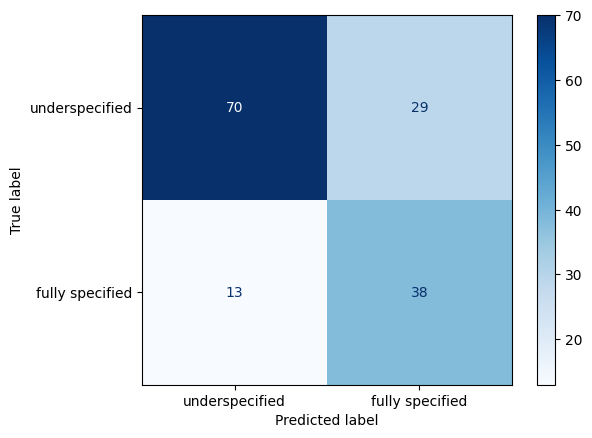

In [9]:
retrieve_results(test_df, "Qwen3_32B_verified_test")